# ML-10 - Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AshenDary/Week1_RunTheStarterNotebooks/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This notebook turns the Week-6 honest grouped model score into a reviewer-facing action queue. The ranking source is `grouped_probability`, re-derived with the same depth-4 `DecisionTreeClassifier`, same seven Week-5 features, and `GroupKFold(client_id)` scoring design.

## 1. Ranked actions + reason codes

The queue ranks pages by the honest grouped score, then uses the same deterministic tie-breakers from Weeks 5-6: higher `impressions_90d`, higher `ctr_gap_score`, then `content_id` as a stable sorter only. The reason codes below are built from the seven real model features and the grouped score, not from the fuller reference pipeline's extra features.

Reason-code thresholds used in code:

| Reason code | Exact threshold |
|---|---|
| `REASON_HIGH_MODEL_RISK` | `grouped_probability >= 0.65` |
| `REASON_LOW_CTR_VISIBLE` | `visible_valid_position == 1` and `ctr_gap_score >= 0.75` |
| `REASON_STALE_VISIBLE` | `visible_valid_position == 1`, `freshness_score >= 0.50`, and `ctr_gap_score < 0.75` |
| `REASON_HIGH_CONFIDENCE_HIGH_VOLUME` | `grouped_probability >= 0.75` and `log_impressions_90d >= log1p(500)` |
| `REASON_HIGH_RISK_LOW_VOLUME` | `grouped_probability >= 0.65` and `log_impressions_90d < log1p(100)` |
| `REASON_PAGE_ONE_DECAY_RISK` | `0 < avg_position <= 10` and `freshness_score >= 0.50` |

The stale-visible archetype connects to the Week-6 paper audit finding that content health peaked around 61-90 days, dropped sharply around 271-365 days, and the 365+ rebound was concentrated in refreshed older pages. The safe reading is selection-aware: refreshed older pages may have been chosen because they already looked like stronger candidates, so the pattern supports review prioritization, not a claim that refresh alone created the rebound.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
N_SPLITS = 5
TREE_MAX_DEPTH = 4
MIN_SAMPLES_LEAF = 100

HIGH_MODEL_RISK = 0.65
HIGH_CONFIDENCE_RISK = 0.75
LOW_CTR_GAP = 0.75
STALE_FRESHNESS_SCORE = 0.50
LOW_VOLUME_LOG_IMPRESSIONS = float(np.log1p(100))
HIGH_VOLUME_LOG_IMPRESSIONS = float(np.log1p(500))
REVIEW_MINUTES_PER_PAGE = 12


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data/raw/content_refresh_anonymized.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find data/raw/content_refresh_anonymized.csv")


def expected_ctr_by_position(avg_position: pd.Series) -> pd.Series:
    return pd.Series(
        np.select(
            [
                avg_position.between(0.01, 3, inclusive="both"),
                avg_position.between(3.01, 10, inclusive="both"),
                avg_position.between(10.01, 20, inclusive="both"),
            ],
            [2.00, 1.00, 0.50],
            default=np.nan,
        ),
        index=avg_position.index,
    )


def build_model_frame(raw_frame: pd.DataFrame) -> pd.DataFrame:
    frame = raw_frame.copy()
    frame["is_declining_label"] = frame["trend_direction"].eq("down").astype(int)
    frame["expected_ctr"] = expected_ctr_by_position(frame["avg_position"])
    frame["visible_valid_position"] = (
        frame["impressions_90d"].ge(300)
        & frame["avg_position"].gt(0)
        & frame["avg_position"].le(20)
    ).astype(int)
    frame["ctr_gap_score"] = (
        (frame["expected_ctr"] - frame["ctr"]) / frame["expected_ctr"]
    ).clip(lower=0, upper=1).fillna(0.0)
    frame["log_impressions_90d"] = np.log1p(frame["impressions_90d"])
    frame["freshness_score"] = (frame["days_since_last_update"] / 180).clip(lower=0, upper=1)
    return frame


def clean_feature_frame(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    features = frame[columns].apply(pd.to_numeric, errors="coerce")
    features = features.replace([np.inf, -np.inf], np.nan)
    return features.fillna(features.median(numeric_only=True))


def train_tree() -> DecisionTreeClassifier:
    return DecisionTreeClassifier(
        max_depth=TREE_MAX_DEPTH,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )


def ranked_by_score(frame: pd.DataFrame, score_col: str) -> pd.DataFrame:
    return frame.sort_values(
        [score_col, "impressions_90d", "ctr_gap_score", "content_id"],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)


def precision_at_k_from_ranked(ranked_frame: pd.DataFrame, k: int) -> float:
    return float(ranked_frame.head(k)["is_declining_label"].mean())


def grouped_oof_scores(X: pd.DataFrame, y: pd.Series, groups: pd.Series) -> np.ndarray:
    scores = np.zeros(len(X), dtype=float)
    splitter = GroupKFold(n_splits=N_SPLITS)
    for train_idx, test_idx in splitter.split(X, y, groups):
        tree = train_tree()
        tree.fit(X.iloc[train_idx], y.iloc[train_idx])
        scores[test_idx] = tree.predict_proba(X.iloc[test_idx])[:, 1]
    return scores


def reason_codes_for_row(row: pd.Series) -> str:
    codes: list[str] = []
    if row["grouped_probability"] >= HIGH_MODEL_RISK:
        codes.append("REASON_HIGH_MODEL_RISK")
    if row["visible_valid_position"] == 1 and row["ctr_gap_score"] >= LOW_CTR_GAP:
        codes.append("REASON_LOW_CTR_VISIBLE")
    if (
        row["visible_valid_position"] == 1
        and row["freshness_score"] >= STALE_FRESHNESS_SCORE
        and row["ctr_gap_score"] < LOW_CTR_GAP
    ):
        codes.append("REASON_STALE_VISIBLE")
    if (
        row["grouped_probability"] >= HIGH_CONFIDENCE_RISK
        and row["log_impressions_90d"] >= HIGH_VOLUME_LOG_IMPRESSIONS
    ):
        codes.append("REASON_HIGH_CONFIDENCE_HIGH_VOLUME")
    if (
        row["grouped_probability"] >= HIGH_MODEL_RISK
        and row["log_impressions_90d"] < LOW_VOLUME_LOG_IMPRESSIONS
    ):
        codes.append("REASON_HIGH_RISK_LOW_VOLUME")
    if (
        row["avg_position"] > 0
        and row["avg_position"] <= 10
        and row["freshness_score"] >= STALE_FRESHNESS_SCORE
    ):
        codes.append("REASON_PAGE_ONE_DECAY_RISK")
    return "|".join(codes) if codes else "REASON_GENERAL_MODEL_RANK"


def assign_archetype(row: pd.Series) -> str:
    codes = set(row["reason_codes"].split("|"))
    if "REASON_HIGH_CONFIDENCE_HIGH_VOLUME" in codes:
        return "High-confidence decline risk, high volume"
    if "REASON_LOW_CTR_VISIBLE" in codes:
        return "Visible, underperforming CTR"
    if "REASON_STALE_VISIBLE" in codes or "REASON_PAGE_ONE_DECAY_RISK" in codes:
        return "Stale but visible"
    if "REASON_HIGH_RISK_LOW_VOLUME" in codes:
        return "High-risk low-volume watchlist"
    if "REASON_HIGH_MODEL_RISK" in codes:
        return "Model-risk review candidate"
    return "Lower-priority monitor"


ACTION_BY_ARCHETYPE = {
    "High-confidence decline risk, high volume": "PRIORITY_REVIEW",
    "Visible, underperforming CTR": "FIX_TITLE_META_REFRESH",
    "Stale but visible": "REFRESH_CONTENT",
    "High-risk low-volume watchlist": "MONITOR",
    "Model-risk review candidate": "REVIEW",
    "Lower-priority monitor": "MONITOR",
}

REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT / "data/raw/content_refresh_anonymized.csv"
BASELINE_METRICS_PATH = REPO_ROOT / "work/outputs/baseline_action_score_metrics.json"
OUTPUT_DIR = REPO_ROOT / "work/outputs"
FIGURE_DIR = REPO_ROOT / "work/figures"

raw_df = pd.read_csv(DATA_PATH)
baseline_receipt = json.loads(BASELINE_METRICS_PATH.read_text())
model_df = build_model_frame(raw_df)

feature_columns = [
    "ctr",
    "avg_position",
    "visible_valid_position",
    "ctr_gap_score",
    "log_impressions_90d",
    "days_since_last_update",
    "freshness_score",
]
forbidden_inputs = {
    "trend_direction",
    "trend_pct",
    "is_declining_label",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_id",
    "client_id",
}
assert set(feature_columns).isdisjoint(forbidden_inputs)
assert len(model_df) == baseline_receipt["rows"]

X = clean_feature_frame(model_df, feature_columns)
y = model_df["is_declining_label"].astype(int)
groups = model_df["client_id"].fillna("unknown").astype(str)
model_df["grouped_probability"] = grouped_oof_scores(X, y, groups)
assert np.isfinite(model_df["grouped_probability"]).all()

ranked_queue = ranked_by_score(model_df, "grouped_probability")
ranked_queue.insert(0, "rank", np.arange(1, len(ranked_queue) + 1))
ranked_queue["reason_codes"] = ranked_queue.apply(reason_codes_for_row, axis=1)
ranked_queue["archetype"] = ranked_queue.apply(assign_archetype, axis=1)
ranked_queue["action_label"] = ranked_queue["archetype"].map(ACTION_BY_ARCHETYPE)
assert ranked_queue["action_label"].notna().all()

reason_counts = (
    ranked_queue["reason_codes"]
    .str.get_dummies(sep="|")
    .sum()
    .sort_values(ascending=False)
    .rename_axis("reason_code")
    .reset_index(name="rows")
)
archetype_counts = ranked_queue["archetype"].value_counts().rename_axis("archetype").reset_index(name="rows")
action_counts = ranked_queue["action_label"].value_counts().rename_axis("action_label").reset_index(name="rows")

archetype_map = pd.DataFrame(
    [
        {
            "archetype": archetype,
            "signals": signal,
            "action_label": ACTION_BY_ARCHETYPE[archetype],
        }
        for archetype, signal in [
            ("High-confidence decline risk, high volume", "grouped_probability >= 0.75 and impressions_90d >= 500"),
            ("Visible, underperforming CTR", "visible_valid_position = 1 and ctr_gap_score >= 0.75"),
            ("Stale but visible", "visible page with freshness_score >= 0.50 and no severe CTR gap, or page-one decay risk"),
            ("High-risk low-volume watchlist", "grouped_probability >= 0.65 and impressions_90d < 100"),
            ("Model-risk review candidate", "grouped_probability >= 0.65 without a more specific action archetype"),
            ("Lower-priority monitor", "ranked below the high-risk thresholds; keep as queue context, not an urgent action"),
        ]
    ]
)

score_summary = pd.DataFrame(
    {
        "metric": [
            "rows_scored",
            "clients",
            "base_declining_rate",
            "grouped_precision_at_10",
            "grouped_precision_at_50",
            "grouped_precision_at_500",
            "grouped_roc_auc_diagnostic",
            "grouped_average_precision_diagnostic",
        ],
        "value": [
            len(ranked_queue),
            ranked_queue["client_id"].nunique(),
            round(float(y.mean()), 4),
            round(precision_at_k_from_ranked(ranked_queue, 10), 4),
            round(precision_at_k_from_ranked(ranked_queue, 50), 4),
            round(precision_at_k_from_ranked(ranked_queue, 500), 4),
            round(float(roc_auc_score(y, ranked_queue.sort_values("content_id")["grouped_probability"])), 4),
            round(float(average_precision_score(y, model_df["grouped_probability"])), 4),
        ],
    }
)

review_hours_top50 = 50 * REVIEW_MINUTES_PER_PAGE / 60
review_hours_top500 = 500 * REVIEW_MINUTES_PER_PAGE / 60
p50 = precision_at_k_from_ranked(ranked_queue, 50)
p500 = precision_at_k_from_ranked(ranked_queue, 500)
cost_value_note = pd.DataFrame(
    [
        {
            "queue_depth": "top_50",
            "assumed_minutes_per_page": REVIEW_MINUTES_PER_PAGE,
            "review_hours": review_hours_top50,
            "measured_precision": p50,
            "observed_right_picks": p50 * 50,
            "observed_right_picks_per_hour": (p50 * 50) / review_hours_top50,
        },
        {
            "queue_depth": "top_500",
            "assumed_minutes_per_page": REVIEW_MINUTES_PER_PAGE,
            "review_hours": review_hours_top500,
            "measured_precision": p500,
            "observed_right_picks": p500 * 500,
            "observed_right_picks_per_hour": (p500 * 500) / review_hours_top500,
        },
    ]
).round(4)

print("Score and validation receipt:")
display(score_summary)
print("Archetype definitions used for action labels:")
display(archetype_map)
print("Rows by archetype:")
display(archetype_counts)
print("Rows by reason code:")
display(reason_counts)
print("Cost/value note using a stated review-time assumption, not dollar ROI:")
display(cost_value_note)
print("Top 10 queue preview with IDs withheld:")
display(ranked_queue[["rank", "grouped_probability", "reason_codes", "archetype", "action_label", "impressions_90d", "ctr", "avg_position", "days_since_last_update", "ctr_gap_score"]].head(10))

assert round(p50, 4) == 0.76
assert ranked_queue.head(50)["is_declining_label"].sum() == 38

Score and validation receipt:


,metric,value
0,rows_scored,30000.0000
1,clients,32.0000
2,base_declining_rate,0.5421
3,grouped_precision_at_10,0.5000
4,grouped_precision_at_50,0.7600
5,grouped_precision_at_500,0.7320
6,grouped_roc_auc_diagnostic,0.5024
7,grouped_average_precision_diagnostic,0.6147


Archetype definitions used for action labels:


,archetype,signals,action_label
0,"High-confidence decline risk, high volume",grouped_probability >= 0.75 and impressions_90...,PRIORITY_REVIEW
1,"Visible, underperforming CTR",visible_valid_position = 1 and ctr_gap_score >...,FIX_TITLE_META_REFRESH
2,Stale but visible,visible page with freshness_score >= 0.50 and ...,REFRESH_CONTENT
3,High-risk low-volume watchlist,grouped_probability >= 0.65 and impressions_90...,MONITOR
4,Model-risk review candidate,grouped_probability >= 0.65 without a more spe...,REVIEW
5,Lower-priority monitor,ranked below the high-risk thresholds; keep as...,MONITOR


Rows by archetype:


...

,reason_code,rows
0,REASON_GENERAL_MODEL_RANK,18453
1,REASON_LOW_CTR_VISIBLE,6496
2,REASON_HIGH_MODEL_RISK,5991
3,REASON_PAGE_ONE_DECAY_RISK,3739
4,REASON_STALE_VISIBLE,2228
5,REASON_HIGH_RISK_LOW_VOLUME,449
6,REASON_HIGH_CONFIDENCE_HIGH_VOLUME,272


Cost/value note using a stated review-time assumption, not dollar ROI:


,queue_depth,assumed_minutes_per_page,review_hours,measured_precision,observed_right_picks,observed_right_picks_per_hour
0,top_50,12,10.0,0.760,38.0,3.80
1,top_500,12,100.0,0.732,366.0,3.66


Top 10 queue preview with IDs withheld:


,rank,grouped_probability,reason_codes,archetype,action_label,impressions_90d,ctr,avg_position,days_since_last_update,ctr_gap_score
0,1,0.79569,REASON_HIGH_MODEL_RISK|REASON_LOW_CTR_VISIBLE|...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,272144,0.03,2.3,20,0.985
1,2,0.79569,REASON_HIGH_MODEL_RISK|REASON_LOW_CTR_VISIBLE|...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,89761,0.09,4.0,20,0.910
2,3,0.79569,REASON_HIGH_MODEL_RISK|REASON_LOW_CTR_VISIBLE|...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,46866,0.03,4.6,40,0.970
3,4,0.79569,REASON_HIGH_MODEL_RISK|REASON_LOW_CTR_VISIBLE|...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,43920,0.06,3.7,26,0.940
4,5,0.79569,REASON_HIGH_MODEL_RISK|REASON_LOW_CTR_VISIBLE|...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,42310,0.13,3.5,104,0.870
5,6,0.79569,REASON_HIGH_MODEL_RISK|REASON_LOW_CTR_VISIBLE|...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,39852,0.07,5.0,104,0.930
6,7,0.79569,REASON_HIGH_MODEL_RISK|REASON_LOW_CTR_VISIBLE|...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,34721,0.25,2.6,14,0.875
7,8,0.79569,REASON_HIGH_MODEL_RISK|REASON_LOW_CTR_VISIBLE|...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,24155,0.05,3.2,41,0.950
8,9,0.79569,REASON_HIGH_MODEL_RISK|REASON_LOW_CTR_VISIBLE|...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,22668,0.04,5.0,40,0.960
9,10,0.79569,REASON_HIGH_MODEL_RISK|REASON_LOW_CTR_VISIBLE|...,"High-confidence decline risk, high volume",PRIORITY_REVIEW,11905,0.01,4.8,8,0.990


## 2. Intended use and limits

This queue ranks pages for a human reviewer to inspect first. It does not decide, publish, edit, de-index, bill, or make client-facing performance judgments by itself.

Limits:

- Single 90-day snapshot, not a time-aware panel. The observed score is useful for queue ordering on this slice, but it is not a forward-looking outcome claim.
- Only 32 pseudonymized clients, with uneven row counts. The Week-6 grouped audit showed that one client can dominate a validation fold, so a new or very different client needs revalidation before this ranking is trusted.
- The target is a proxy label: `trend_direction == "down"`. It is measured from the current trend definition, not verified future business impact.
- The depth-4 tree is intentionally simple. It may miss patterns a richer model catches, but it stays readable for a non-technical reviewer, which is the design goal here.
- The stale/refresh connection is observational. Refreshed older pages may have been selected because they already looked promising, so this queue supports review prioritization rather than causal refresh claims.

In [2]:
limits_table = pd.DataFrame(
    [
        {
            "limit": "single_snapshot",
            "what_it_means": "The starter data is one trailing-90-day snapshot.",
            "decision_rule": "Use the queue for current review ordering, not forward outcome claims.",
        },
        {
            "limit": "client_mix",
            "what_it_means": "The model was validated across 32 pseudonymized clients with uneven fold sizes.",
            "decision_rule": "Revalidate before using the ranking for very different client populations.",
        },
        {
            "limit": "proxy_target",
            "what_it_means": "The label is trend_direction == down, not a verified future recovery outcome.",
            "decision_rule": "Describe pages as review candidates, not certain wins.",
        },
        {
            "limit": "simple_model",
            "what_it_means": "A depth-4 tree favors explainability over maximum pattern capture.",
            "decision_rule": "Use reason codes and human checks before action.",
        },
    ]
)
display(limits_table)
assert set(limits_table["limit"]) == {"single_snapshot", "client_mix", "proxy_target", "simple_model"}

,limit,what_it_means,decision_rule
0,single_snapshot,The starter data is one trailing-90-day snapshot.,"Use the queue for current review ordering, not..."
1,client_mix,The model was validated across 32 pseudonymize...,Revalidate before using the ranking for very d...
2,proxy_target,"The label is trend_direction == down, not a ve...","Describe pages as review candidates, not certa..."
3,simple_model,A depth-4 tree favors explainability over maxi...,Use reason codes and human checks before action.


## 3. Human review + the no-go list

Before acting on any row, a reviewer checks that the page is still live, the content is accurate, the page has enough volume to matter, and the measured drop is not better explained by a sibling page absorbing demand, a calendar-driven dip, SERP or AI click loss, or small-sample noise.

No-go list:

- No auto-publishing or auto-editing content from this queue.
- No auto-deprioritizing or de-indexing content based on the score alone.
- No client-facing billing, contract, or performance decisions based on this score.
- No extrapolating the ranking to clients or content types outside the 32-client training set without revalidating first.

In [3]:
human_review_checklist = pd.DataFrame(
    [
        {
            "check": "page_live",
            "question": "Is the page still live and indexable?",
            "reason": "A dead or redirected page needs a different workflow than refresh review.",
        },
        {
            "check": "content_accuracy",
            "question": "Is the content still factually accurate and current?",
            "reason": "Accuracy problems change the action from metadata tuning to content repair.",
        },
        {
            "check": "consolidation",
            "question": "Did a sibling page absorb the same demand?",
            "reason": "A transfer inside the same site is not the same problem as standalone decline.",
        },
        {
            "check": "seasonality",
            "question": "Does the topic normally dip in this calendar period?",
            "reason": "A calendar-driven dip needs monitoring or seasonal planning, not a panic refresh.",
        },
        {
            "check": "serp_or_ai_click_loss",
            "question": "Are impressions and position steady while clicks drop?",
            "reason": "SERP layout or AI referral changes can reduce clicks without content decay.",
        },
        {
            "check": "noise",
            "question": "Is the page too low-volume for the movement to be meaningful?",
            "reason": "Small counts can create large-looking swings.",
        },
    ]
)
display(human_review_checklist)
assert len(human_review_checklist) == 6

,check,question,reason
0,page_live,Is the page still live and indexable?,A dead or redirected page needs a different wo...
1,content_accuracy,Is the content still factually accurate and cu...,Accuracy problems change the action from metad...
2,consolidation,Did a sibling page absorb the same demand?,A transfer inside the same site is not the sam...
3,seasonality,Does the topic normally dip in this calendar p...,A calendar-driven dip needs monitoring or seas...
4,serp_or_ai_click_loss,Are impressions and position steady while clic...,SERP layout or AI referral changes can reduce ...
5,noise,Is the page too low-volume for the movement to...,Small counts can create large-looking swings.


## 4. Monitoring / retrain triggers

The monitoring plan is intentionally light. These triggers say when to pause, re-check, or rebuild the queue rather than treating old scores as stable facts.

In [4]:
monitoring_triggers = pd.DataFrame(
    [
        {
            "trigger": "Precision@50 on a fresh manually reviewed batch drops well below ~0.76",
            "what_it_means": "The ranking is no longer finding review candidates at the measured Week-6 rate.",
            "what_to_do": "Pause the queue, then re-check features, labels, and reason-code thresholds.",
        },
        {
            "trigger": "Client mix drifts far from the 32-client training distribution",
            "what_it_means": "New client types may behave differently from the grouped validation sample.",
            "what_to_do": "Revalidate on the new client mix before trusting the ranking.",
        },
        {
            "trigger": "The 90-day snapshot ages past about 2 quarters",
            "what_it_means": "The feature values and content state are stale.",
            "what_to_do": "Rebuild the feature snapshot before ranking again.",
        },
        {
            "trigger": "A new content type appears with different missingness patterns",
            "what_it_means": "Feature assumptions from the starter data may not hold.",
            "what_to_do": "Re-run leakage and signal checks on the new slice.",
        },
    ]
)
display(monitoring_triggers)
assert len(monitoring_triggers) == 4

,trigger,what_it_means,what_to_do
0,Precision@50 on a fresh manually reviewed batc...,The ranking is no longer finding review candid...,"Pause the queue, then re-check features, label..."
1,Client mix drifts far from the 32-client train...,New client types may behave differently from t...,Revalidate on the new client mix before trusti...
2,The 90-day snapshot ages past about 2 quarters,The feature values and content state are stale.,Rebuild the feature snapshot before ranking ag...
3,A new content type appears with different miss...,Feature assumptions from the starter data may ...,Re-run leakage and signal checks on the new sl...


## 5. Exports for the paper

This section writes the local action queue CSV, two paper-ready figures, and a small metrics JSON receipt. The CSV stays ignored by git under `work/outputs/`; the figures and JSON receipt are small enough to commit.

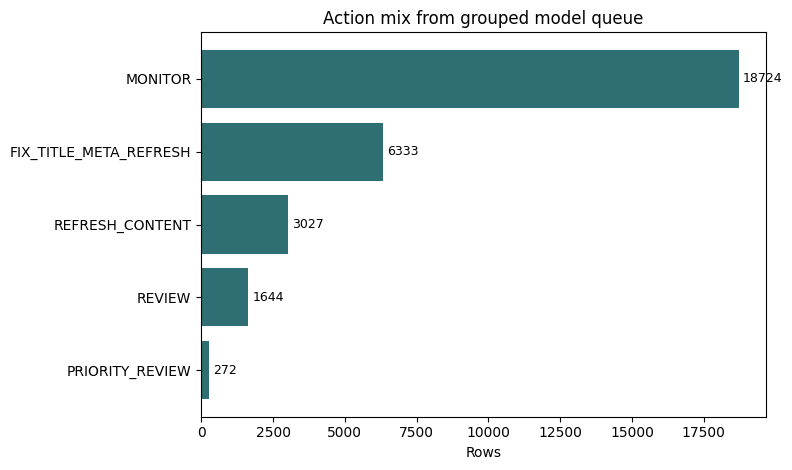

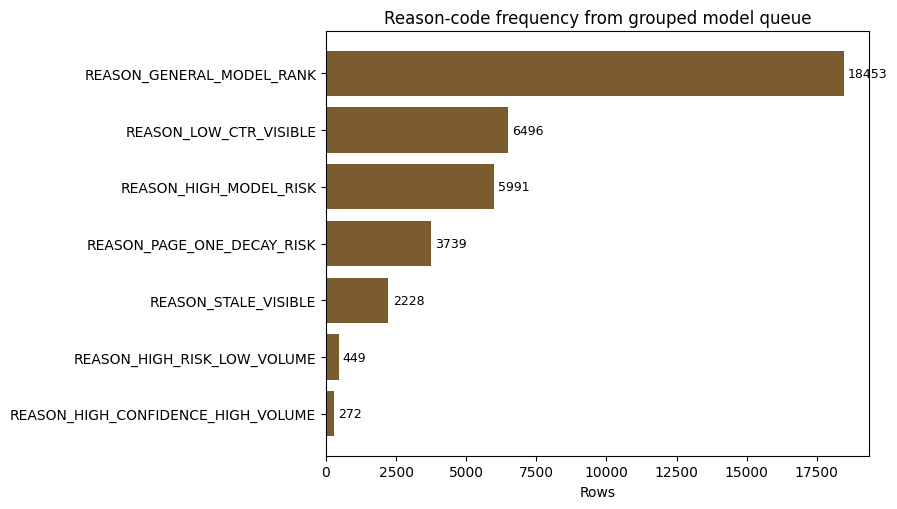

,artifact,path,rows
0,ranked_queue_csv,work/outputs/w07_grouped_action_queue.csv,30000
1,metrics_json,work/outputs/w07_action_playbook_metrics.json,1
2,action_mix_figure,work/figures/w07_action_mix.png,5
3,reason_code_figure,work/figures/w07_reason_code_frequency.png,7


{
  "rows_scored": 30000,
  "clients": 32,
  "base_declining_rate": 0.5421,
  "grouped_precision_at_10": 0.5,
  "grouped_precision_at_50": 0.76,
  "grouped_precision_at_500": 0.732,
  "top50_observed_right_picks": 38,
  "top500_observed_right_picks": 366,
  "review_minutes_per_page_assumption": 12,
  "top50_review_hours": 10.0,
  "top500_review_hours": 100.0,
  "top50_observed_right_picks_per_hour": 3.8,
  "top500_observed_right_picks_per_hour": 3.66,
  "archetype_counts": {
    "Lower-priority monitor": 18453,
    "Visible, underperforming CTR": 6333,
    "Stale but visible": 3027,
    "Model-risk review candidate": 1644,
    "High-confidence decline risk, high volume": 272,
    "High-risk low-volume watchlist": 271
  },
  "action_counts": {
    "MONITOR": 18724,
    "FIX_TITLE_META_REFRESH": 6333,
    "REFRESH_CONTENT": 3027,
    "REVIEW": 1644,
    "PRIORITY_REVIEW": 272
  },
  "reason_code_counts": {
    "REASON_GENERAL_MODEL_RANK": 18453,
    "REASON_LOW_CTR_VISIBLE": 6496,
    "R

In [5]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

queue_columns = [
    "rank",
    "content_id",
    "client_id",
    "grouped_probability",
    "reason_codes",
    "archetype",
    "action_label",
    "impressions_90d",
    "ctr",
    "avg_position",
    "visible_valid_position",
    "ctr_gap_score",
    "log_impressions_90d",
    "days_since_last_update",
    "freshness_score",
]
queue_path = OUTPUT_DIR / "w07_grouped_action_queue.csv"
metrics_path = OUTPUT_DIR / "w07_action_playbook_metrics.json"
action_figure_path = FIGURE_DIR / "w07_action_mix.png"
reason_figure_path = FIGURE_DIR / "w07_reason_code_frequency.png"

ranked_queue[queue_columns].to_csv(queue_path, index=False)

plt.style.use("default")
fig, ax = plt.subplots(figsize=(8, 4.8))
action_plot = action_counts.sort_values("rows", ascending=True)
ax.barh(action_plot["action_label"], action_plot["rows"], color="#2f6f73")
ax.set_title("Action mix from grouped model queue")
ax.set_xlabel("Rows")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
fig.tight_layout()
fig.savefig(action_figure_path, dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5.2))
reason_plot = reason_counts.sort_values("rows", ascending=True)
ax.barh(reason_plot["reason_code"], reason_plot["rows"], color="#7a5c2e")
ax.set_title("Reason-code frequency from grouped model queue")
ax.set_xlabel("Rows")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
fig.tight_layout()
fig.savefig(reason_figure_path, dpi=160)
plt.show()

metrics_payload = {
    "rows_scored": int(len(ranked_queue)),
    "clients": int(ranked_queue["client_id"].nunique()),
    "base_declining_rate": round(float(y.mean()), 4),
    "grouped_precision_at_10": round(float(precision_at_k_from_ranked(ranked_queue, 10)), 4),
    "grouped_precision_at_50": round(float(precision_at_k_from_ranked(ranked_queue, 50)), 4),
    "grouped_precision_at_500": round(float(precision_at_k_from_ranked(ranked_queue, 500)), 4),
    "top50_observed_right_picks": int(ranked_queue.head(50)["is_declining_label"].sum()),
    "top500_observed_right_picks": int(ranked_queue.head(500)["is_declining_label"].sum()),
    "review_minutes_per_page_assumption": REVIEW_MINUTES_PER_PAGE,
    "top50_review_hours": round(float(review_hours_top50), 2),
    "top500_review_hours": round(float(review_hours_top500), 2),
    "top50_observed_right_picks_per_hour": round(float((p50 * 50) / review_hours_top50), 4),
    "top500_observed_right_picks_per_hour": round(float((p500 * 500) / review_hours_top500), 4),
    "archetype_counts": {row["archetype"]: int(row["rows"]) for _, row in archetype_counts.iterrows()},
    "action_counts": {row["action_label"]: int(row["rows"]) for _, row in action_counts.iterrows()},
    "reason_code_counts": {row["reason_code"]: int(row["rows"]) for _, row in reason_counts.iterrows()},
    "ranking_source": "grouped_probability from GroupKFold(client_id) out-of-fold scoring",
    "queue_path": str(queue_path.relative_to(REPO_ROOT)),
    "figure_paths": [str(action_figure_path.relative_to(REPO_ROOT)), str(reason_figure_path.relative_to(REPO_ROOT))],
}
metrics_path.write_text(json.dumps(metrics_payload, indent=2) + "\n")

export_receipt = pd.DataFrame(
    [
        {"artifact": "ranked_queue_csv", "path": str(queue_path.relative_to(REPO_ROOT)), "rows": len(ranked_queue)},
        {"artifact": "metrics_json", "path": str(metrics_path.relative_to(REPO_ROOT)), "rows": 1},
        {"artifact": "action_mix_figure", "path": str(action_figure_path.relative_to(REPO_ROOT)), "rows": len(action_counts)},
        {"artifact": "reason_code_figure", "path": str(reason_figure_path.relative_to(REPO_ROOT)), "rows": len(reason_counts)},
    ]
)
display(export_receipt)
print(json.dumps(metrics_payload, indent=2))

assert queue_path.exists() and queue_path.stat().st_size > 0
assert metrics_path.exists() and metrics_path.stat().st_size > 0
assert action_figure_path.exists() and action_figure_path.stat().st_size > 0
assert reason_figure_path.exists() and reason_figure_path.stat().st_size > 0

## Self-check

- [x] Every section filled: markdown thinking and code receipts are both present
- [x] Runs top to bottom with no errors
- [x] No client names, URLs, or private queries are printed
- [x] Claims use careful words: observed, measured, directional, and decision-support
- [x] Ranked queue CSV is written locally to `work/outputs/` and stays ignored by git
- [x] Figures are written to `work/figures/` for the paper
- [x] Metrics JSON is written to `work/outputs/` as a receipt
- [x] Committed to `work/notebooks/` after execution